# Double 7's Portfolio (Short Term Trading Strategies that Work)

    1. The Security is above its 200-day moving average or X-day ma
    2. The Security closes at a 7-day low, buy.
    3. If the Security closes at a 7-day high, sell your long position.
    
    (For a Portfolio of securities.)

In [1]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd

import pinkfish as pf
import strategy

# Format price data.
pd.options.display.float_format = '{:0.2f}'.format

%matplotlib inline

In [2]:
# Set size of inline plots
'''note: rcParams can't be in same cell as import matplotlib
   or %matplotlib inline
   
   %matplotlib notebook: will lead to interactive plots embedded within
   the notebook, you can zoom and resize the figure
   
   %matplotlib inline: only draw static images in the notebook
'''
plt.rcParams["figure.figsize"] = (10, 7)

Some global data

In [3]:
# Symbol Lists
SP500_Sectors = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']
Mixed_Asset_Classes = ['IWB', 'SPY', 'VGK', 'IEV', 'EWJ', 'EPP', 'IEF', 'SHY', 'GLD']
FANG_Stocks = ['FB', 'AMZN', 'NFLX', 'GOOG']
Stocks_Bonds_Gold = ['SPY', 'QQQ', 'TLT', 'GLD']

# Pick one of the above
symbols = Stocks_Bonds_Gold

capital = 10000
start = datetime.datetime(*pf.ALPHA_BEGIN)
#start = datetime.datetime(*pf.SP500_BEGIN)
end = datetime.datetime.now()

In [4]:
options = {
    'use_adj' : False,
    'use_cache' : True,
    'stop_loss_pct' : 0.15,
    'margin' : 3.0,
    'period' : 7,
    'use_regime_filter' : True,
    'use_vola_weight' : True
}

Run Strategy

In [5]:
s = strategy.Strategy(symbols, capital, start, end, options=options)
s.run()

STOP LOSS!!!
STOP LOSS!!!


View log DataFrames: raw trade log, trade log, and daily balance

In [6]:
s.rlog.head()

,date,seq_num,price,shares,entry_exit,direction,symbol
0,2005-09-07,0,93.60,93,entry,LONG,TLT
0,2005-09-14,1,123.21,63,entry,LONG,SPY
0,2005-09-14,2,39.18,195,entry,LONG,QQQ
1,2005-09-29,3,122.66,63,exit,LONG,SPY
1,2005-09-29,4,39.20,195,exit,LONG,QQQ


In [7]:
s.tlog.tail()

,entry_date,entry_price,exit_date,exit_price,pl_points,pl_cash,qty,cumul_total,direction,symbol
181,2026-05-14,427.21,2026-06-08,397.27,-29.94,-6317.34,211,203596.09,LONG,GLD
216,2026-05-18,705.88,2026-05-26,730.28,24.40,4172.40,171,207768.49,LONG,QQQ
206,2026-05-19,733.73,2026-05-26,750.59,16.86,4417.33,262,212185.82,LONG,SPY
207,2026-06-05,737.55,2026-06-08,739.22,1.67,414.16,248,212599.98,LONG,SPY
217,2026-06-05,705.06,2026-06-08,716.07,11.01,1596.45,145,214196.43,LONG,QQQ


In [8]:
s.dbal.tail()

,high,low,close,shares,cash,leverage,state
date,,,,,,,
2026-06-02,225283.31,225283.31,225283.31,211,138361.85,1.00,-
2026-06-03,224422.42,224422.42,224422.42,211,138361.85,1.00,-
2026-06-04,225139.82,225139.82,225139.82,211,138361.85,1.00,-
2026-06-05,221968.49,221968.49,221968.49,604,-146784.24,1.66,O
2026-06-08,224196.43,224196.43,224196.43,0,224196.43,1.00,X


Generate strategy stats - display all available stats

In [9]:
pf.print_full(s.stats)

start                                                  2005-09-02
end                                                    2026-06-08
beginning_balance                                           10000
ending_balance                                          224196.43
total_net_profit                                        214196.43
gross_profit                                            448321.88
gross_loss                                             -234125.45
profit_factor                                                1.91
return_on_initial_capital                                 2141.96
annual_return_rate                                          16.16
trading_period                           20 years 9 months 6 days
pct_time_in_market                                          65.13
margin                                                       3.00
avg_leverage                                                 1.28
max_leverage                                                 3.12
min_levera

View Performance by Symbol

,cumul_total,weight,pct_cumul_total,relative_performance
SPY,"$70,992.10",0.25,0.33,1.33
QQQ,"$80,531.08",0.25,0.38,1.50
GLD,"$48,111.31",0.25,0.22,0.90
TLT,"$14,561.94",0.25,0.07,0.27
TOTAL,"$214,196.43",1.00,1.00,1.00


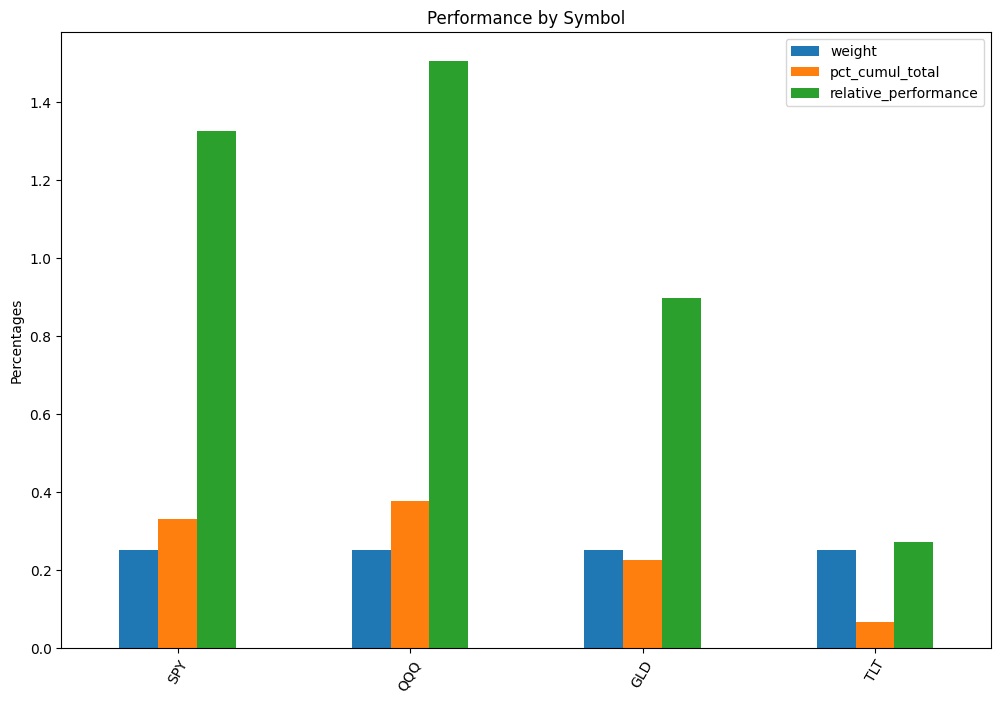

In [10]:
weights = {symbol: 1 / len(symbols) for symbol in symbols}
totals = s.portfolio.performance_per_symbol(weights=weights)
totals

,SPY,QQQ,GLD,TLT
SPY,1.00,0.92,0.06,-0.31
QQQ,0.92,1.00,0.05,-0.25
GLD,0.06,0.05,1.00,0.16
TLT,-0.31,-0.25,0.16,1.00


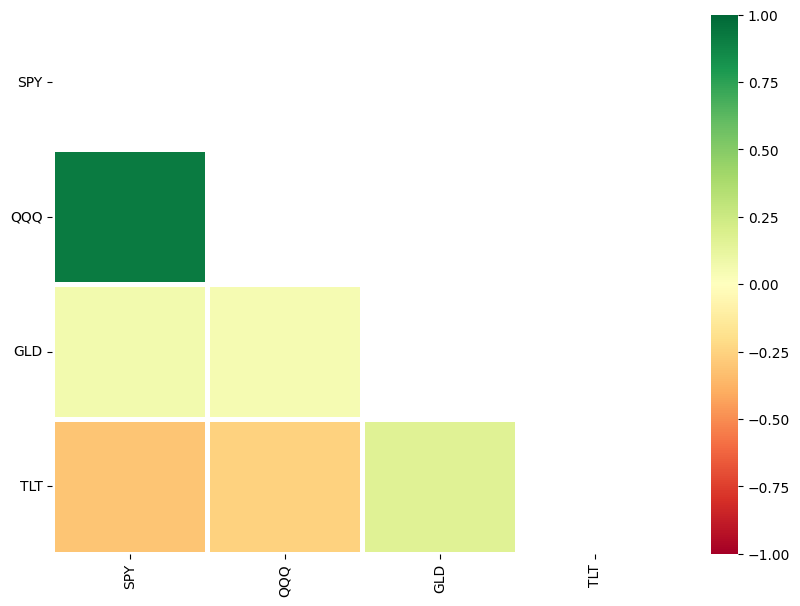

In [11]:
corr_df = s.portfolio.correlation_map(s.ts)
corr_df

Run Benchmark, Retrieve benchmark logs, and Generate benchmark stats

In [12]:
benchmark = pf.Benchmark('SPY', s.capital, s.start, s.end, use_adj=True)
benchmark.run()

Plot Equity Curves: Strategy vs Benchmark

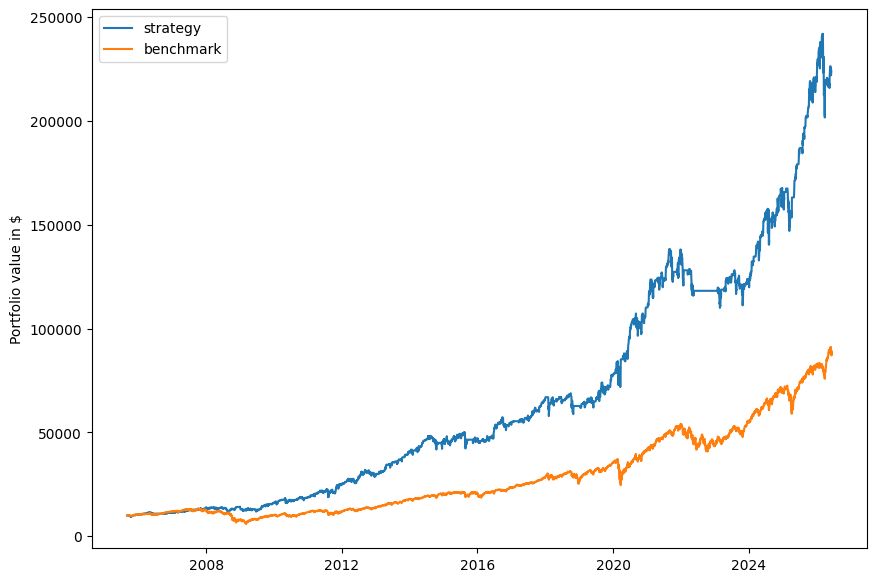

In [13]:
pf.plot_equity_curve(s.dbal, benchmark=benchmark.dbal)

Bar Graph: Strategy vs Benchmark

,strategy,benchmark
annual_return_rate,16.16,11.10
max_closed_out_drawdown,-20.52,-55.00
annualized_return_over_max_drawdown,0.79,0.20
best_month,20.94,23.58
worst_month,-16.22,-30.98
sharpe_ratio,0.94,0.65
sortino_ratio,1.03,0.79
monthly_std,3.85,4.53
annual_std,14.66,16.29


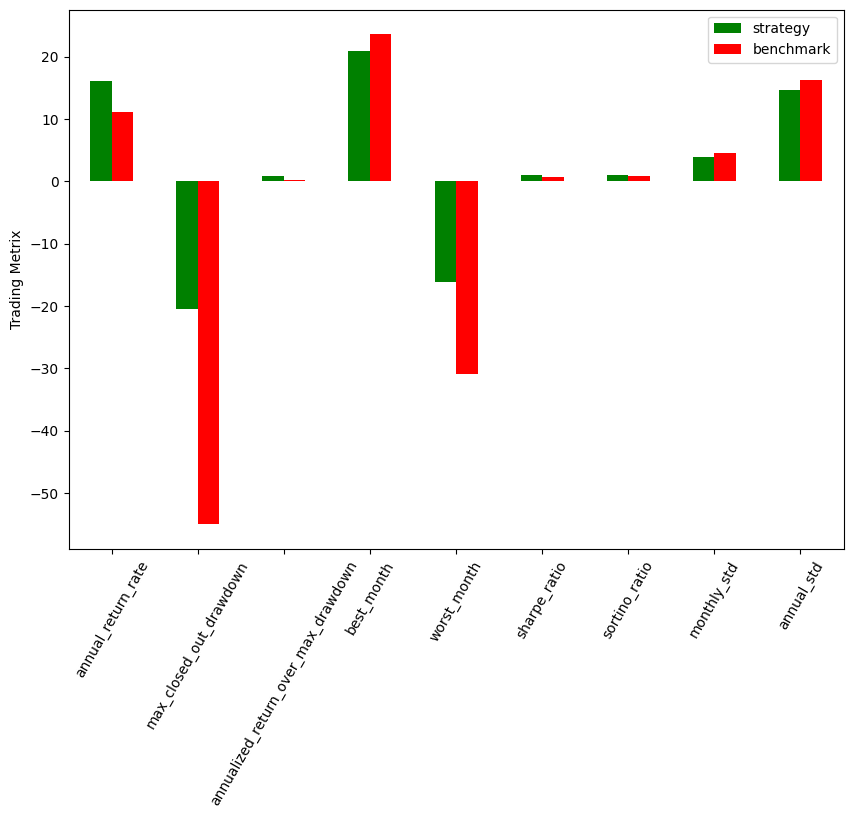

In [14]:
df = pf.plot_bar_graph(s.stats, benchmark.stats)
df

Analysis: Kelly Criterian

In [15]:
kelly = pf.kelly_criterion(s.stats, benchmark.stats)
kelly

sharpe_ratio            0.94
sharpe_ratio_max        0.99
sharpe_ratio_min        0.89
strategy risk           0.15
instrument risk         0.16
optimal target risk     0.94
half kelly criterion    0.47
aggressive leverage     5.76
moderate leverage       2.88
conservative leverage   2.73
dtype: float64